# Notebook classes_histograms

This notebook classifies the wildfires into size classes using the natural breaks and visualizes the size distribution with histograms.

### Input data
- fire_14_23.csv: Cleaned wildfire data for the years 2014 - 2023

### Outputs
Data:
- fire_tot.csv: Cleaned wildfire data for the years 2014 - 2023 including a column with size
- wildfire_14_18.csv: Wildfire data for the year 2014 - 2018 including a column with size
- wildfire_19_23.csv: Wildfire data for the year 2019 - 2023 including a column with size

Histograms:
- histogram_2014_2018.png: Histogram showing the number of wildfires for each class for 2014 - 2018
- histogram_2019_2023.png: Histogram showing the number of wildfires for each class for 2019 - 2023

In [1]:
import pandas as pd

# For the Natural Breaks
import jenkspy 

# For Histogram
import matplotlib.pyplot as plt

In [2]:
# 1. Loading cleand wildfire data for the years 2014 - 2023
fire_14_23 = pd.read_csv("../data/processed/fire_14_23.csv", sep = ",")
print("Data loaded successfully")

Data loaded successfully


In [3]:
# 2. Creating classes for size
data = fire_14_23['size_ha']

# Calculate Natural Breaks (Jenks)
breaks = jenkspy.jenks_breaks(data, n_classes=5)

# Creating labels for the 5 classes
labels = [
    "Very small",
    "Small",
    "Medium",
    "Large",
    "Extremely large"
]

# Create classes
classes = pd.cut(fire_14_23['size_ha'], bins=breaks, include_lowest=True) 

# Count number of fires per class
table = classes.value_counts().sort_index()

# Convert to DataFrame
table = table.reset_index()

# Add column for the size names using the labels
table['size'] = labels

# Order and print table
table.columns = ['class intervals (ha)', 'number of fires', 'size']
table = table[['size', 'class intervals (ha)', 'number of fires']] # reorder the table so that size is first

table

,size,class intervals (ha),number of fires
0,Very small,"(199.999, 23677.9]",3892
1,Small,"(23677.9, 92412.0]",249
2,Medium,"(92412.0, 215280.41]",49
3,Large,"(215280.41, 430000.0]",17
4,Extremely large,"(430000.0, 885388.214]",8


In [4]:
# 3. Adding the labels for the size to the copy csv of fire_14_23
fire_tot = fire_14_23.copy()

fire_tot['size'] = pd.cut(
    fire_tot['size_ha'],
    bins = breaks,
    labels = labels,
    include_lowest = True
)

display(fire_tot.head(5))

,province,fire_id,latitude,longitude,year,size_ha,cause,size
0,Alberta,HWF175,57.552983,-115.553983,2023,251.80000,Unknown,Very small
1,Saskatchewan,23SR-LLHIR03,58.182064,-103.050880,2023,214.70000,Natural,Very small
2,Quebec,20231080689,50.571300,-79.304600,2023,19248.49051,Natural,Very small
3,Saskatchewan,23LA-HARDY,55.622898,-106.395540,2023,314.00000,Natural,Very small
4,Saskatchewan,23BN-LINVALL,56.361978,-109.013426,2023,660.00000,Natural,Very small


In [5]:
# 4. Exporting
# Exporting the fire data which is cleaned and has a column for size
fire_tot.to_csv("../data/processed/fire_tot.csv", index = False)
print("Export fire_tot successful")

# Exporting the fire data of 2014 - 2018
wildfire_14_18 = fire_tot[
    (fire_tot["year"] >= 2014) & 
    (fire_tot["year"] <= 2018)
].copy()

wildfire_14_18.to_csv("../data/processed/wildfire_map/wildfire_14_18.csv", index = False)
print("Export wildfire_14_18 successful")

# Exporting the fire data of 2019 - 2023
wildfire_19_23 = fire_tot[
    (fire_tot["year"] >= 2019) & 
    (fire_tot["year"] <= 2023)
].copy()

wildfire_19_23.to_csv("../data/processed/wildfire_map/wildfire_19_23.csv", index = False)
print("Export wildfire_19_23 successful")

Export fire_tot successful
Export wildfire_14_18 successful
Export wildfire_19_23 successful


## Histograms

The section 3. and 5. will generate histograms. They are for readers to understand what the distribution of the wildfires into the size classes is.

The histogram under 3. will show how many wildfires are in each size class in the time period 2014 - 2018.
The histogram under 5. will show how many wildfires are in each size class in the time period 2019 - 2023.

The section 4. and 6. will generate a table.

Thoes tables show the exact number of wildfires in each size class for the timp periods 2014 - 2018 (under 4.) and 2019 - 2023 (under 6.).
Thoes tables are an addition to the histograms, because the y-axis of the histograms is logarithmic and therfore it is hard to identify the exact number of wildfires in each class.

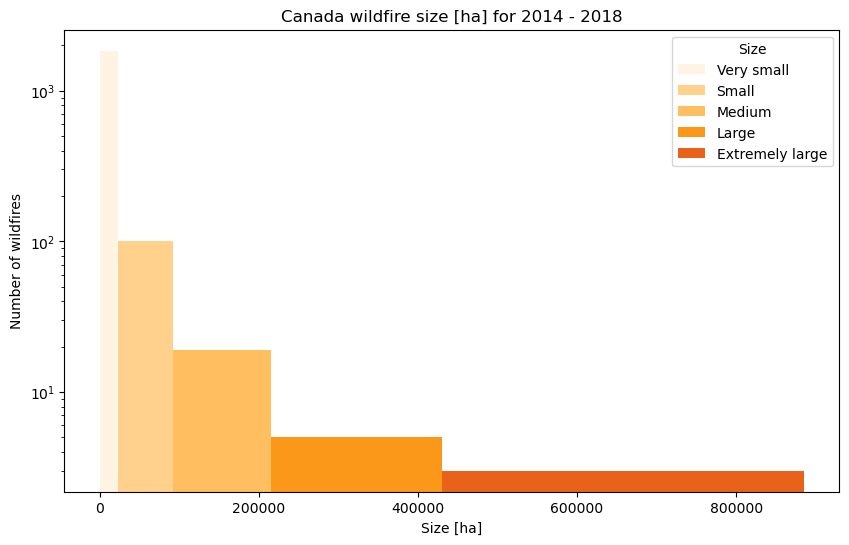

In [6]:
# 3. Histogram for 2014 - 2018 showing each fire colored in their size class
histo_14_18 = wildfire_14_18['size_ha']

# Colors for each class
colors = [
    "#fff3e0",
    "#ffcc80",
    "#ffb74d",
    "#fb8c00",
    "#e65100"
]

# Create figure
plt.figure(figsize=(10,6))

# Plot each class separately
for i in range(len(breaks)-1):

    class_data = histo_14_18[
        (histo_14_18 >= breaks[i]) &
        (histo_14_18 <= breaks[i+1])
    ]

    plt.hist(
        class_data,
        bins=[breaks[i], breaks[i+1]],
        color=colors[i],
        alpha=0.9,
        label=labels[i]
    )

# Logarithmic y-Axis
plt.yscale('log')

# Labels
plt.xlabel('Size [ha]')
plt.ylabel('Number of wildfires')
plt.title('Canada wildfire size [ha] for 2014 - 2018')
plt.legend(title = 'Size')

# Save figure
plt.savefig("../outputs/histogram_2014_2018.png")

# Show plot
plt.show()

In [7]:
# 4. Table for 2014 - 2018, to see the exact number of fires for each size class
table_14_18 = (wildfire_14_18['size'].value_counts().reset_index())

table_14_18.columns = ['size', 'number of fires']

table_14_18

,size,number of fires
0,Very small,1841
1,Small,100
2,Medium,18
3,Large,5
4,Extremely large,3


**Interpretation of histogram:**

Most fires are of the size very small, only 3 fires over the time period 2014 - 2018 are of extremely large size.

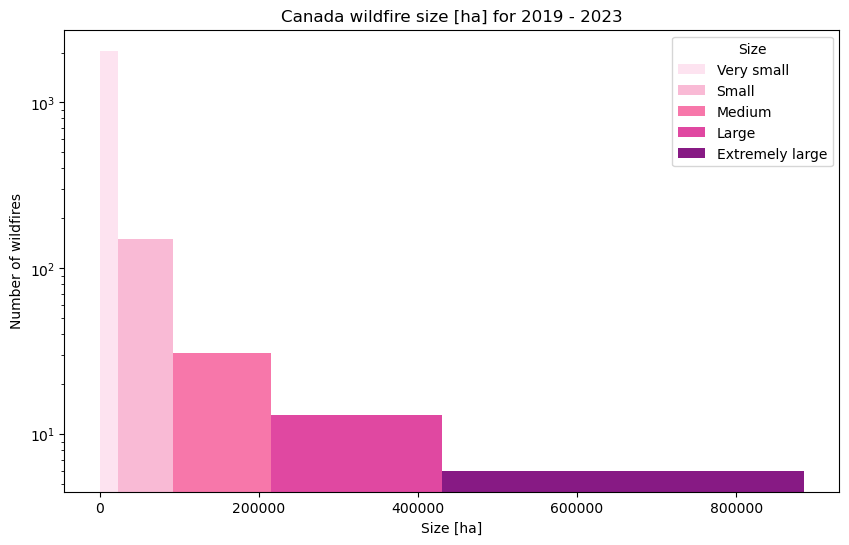

In [8]:
# 5. Histogram for 2019 - 2023 showing each fire colored in their size class

# Years 2019-2023
histo_19_23 = wildfire_19_23['size_ha']

# Colors for each class
colors = [
    "#fde0ef",
    "#f9b3d1",
    "#f768a1",
    "#dd3497",
    "#7a0177"
]

# Create figure
plt.figure(figsize=(10,6))

# Plot each class separately
for i in range(len(breaks)-1):

    class_data = histo_19_23[
        (histo_19_23 >= breaks[i]) &
        (histo_19_23 <= breaks[i+1])
    ]

    plt.hist(
        class_data,
        bins=[breaks[i], breaks[i+1]],
        color=colors[i],
        alpha=0.9,
        label=labels[i]
    )

# Logarithmic y-Axis
plt.yscale('log')

# Labels
plt.xlabel('Size [ha]')
plt.ylabel('Number of wildfires')
plt.title('Canada wildfire size [ha] for 2019 - 2023')
plt.legend(title = 'Size')

# Save figure
plt.savefig("../outputs/histogram_2019_2023.png")

# Show plot
plt.show()

In [9]:
# 6. Table for 2014 - 2023, to see the exact number of fires for each size class
table_19_23 = (wildfire_19_23['size'].value_counts().reset_index())

table_19_23.columns = ['size', 'number of fires']

table_19_23

,size,number of fires
0,Very small,2051
1,Small,149
2,Medium,31
3,Large,12
4,Extremely large,5


**Interpretation of histogram:**

Most fires are of the size very small, only 5 fires over the time period 2019 - 2023 are of extremely large size. In comparison to the timpe period 2014 - 2018 there are in all size classes more wildfires.